<a href="https://colab.research.google.com/github/UlaStats/Data-analysis-poster/blob/main/MSc_project_data_pre_processing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data Import

In [ ]:
# upload into working space
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# import data

import pandas as pd

assets = pd.read_csv("/content/drive/MyDrive/MSc project/Assets.csv", encoding='latin1')
bursts = pd.read_csv("/content/drive/MyDrive/MSc project/burst_data.csv", encoding='latin1')
soil = pd.read_csv("/content/drive/MyDrive/MSc project/soil-pipe-matched.csv", encoding ='latin1')

/tmp/ipykernel_2788/3375540221.py:5: DtypeWarning: Columns (22,23,28) have mixed types. Specify dtype option on import or set low_memory=False.
  assets = pd.read_csv("/content/drive/MyDrive/MSc project/Assets.csv", encoding='latin1')


# Data Cleaning

In [ ]:
# assets cleaning

assets_cleaned = assets[assets["Type"] == "Distribution"] # only keeping distribution mains

assets_cleaned = assets_cleaned[pd.notnull(assets_cleaned["ARM_DIAMETER"])] # deletes records with missing diameter

assets_cleaned = assets_cleaned[(assets_cleaned["Operational.Status"] != "Abandoned")] # deletes abandoned assets

assets_cleaned = assets_cleaned[(assets_cleaned["Operational.Status"] != "Removed")] # deletes removed assets

assets_cleaned = assets_cleaned[["Asset.ID", "ARM_MATERIAL", "ARM_DIAMETER", "ARM_LENGTH", "ARM_AGE", "ARM_LINING"]] # selecting attributes

assets_cleaned = assets_cleaned.rename(columns = {"ARM_MATERIAL":"Material",
                                                        "ARM_DIAMETER": "Diameter",
                                                        "ARM_LENGTH": "Length",
                                                        "ARM_AGE": "Age",
                                                        "ARM_LINING": "Lining"}) # renaming columns

<Axes: title={'center': 'No. of assets by material type'}, xlabel='Material', ylabel='No. of assets'>

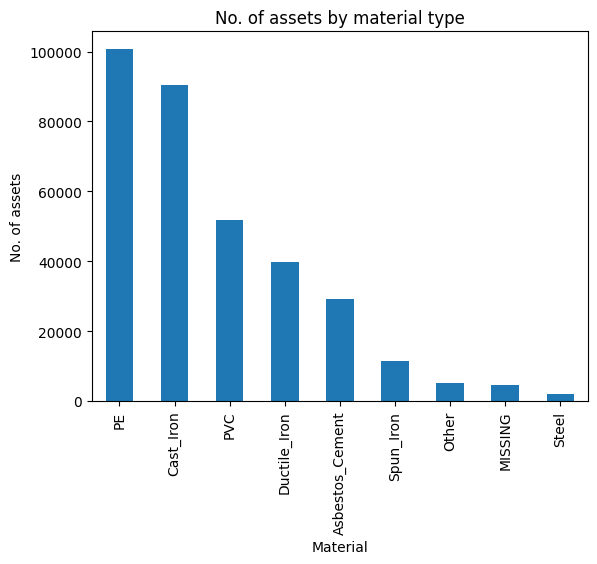

In [ ]:
# plotting

assets_attributes["Material"].value_counts().plot(kind = "bar",
                                                  ylabel = "No. of assets",
                                                  title = "No. of assets by material type")

In [ ]:
# bursts cleaning

bursts_cleaned = bursts[["Asset.ID", "Raised.Date"]]

bursts_cleaned["Raised.Date"] = pd.to_datetime(bursts_cleaned["Raised.Date"], dayfirst=True) # transofrms burst date to date format

/tmp/ipykernel_2788/17490745.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  bursts_cleaned["Raised.Date"] = pd.to_datetime(bursts_cleaned["Raised.Date"], dayfirst=True) # transofrms burst date to date format


In [ ]:
# soil cleaning

soil = soil[["Asset.ID", "Soil"]]

In [ ]:
# merging assets, bursts and soil together

assets_bursts = pd.merge(assets_cleaned, bursts_cleaned, how = "left", on = "Asset.ID")

assets_bursts = assets_bursts[pd.notnull(assets_bursts["Raised.Date"])] # removing assets without bursts

assets_bursts_soil = pd.merge(assets_bursts, soil, how = "left", on = "Asset.ID")

assets_bursts_soil = assets_bursts_soil[pd.notnull(assets_bursts_soil["Soil"])] # removing assets without soil information

In [ ]:
# identify assets with 2 or more bursts

counts = bursts["Asset.ID"].value_counts()
frequent_bursters = counts[counts >= 2].index



In [ ]:
# filter merged data for assets with 2 or more bursts

assets_bursts_soil_frequent = assets_bursts_soil[assets_bursts_soil["Asset.ID"].isin(frequent_bursters)]

<Axes: title={'center': 'No. of assets with >= 2 bursts'}, xlabel='Material', ylabel='No. of assets'>

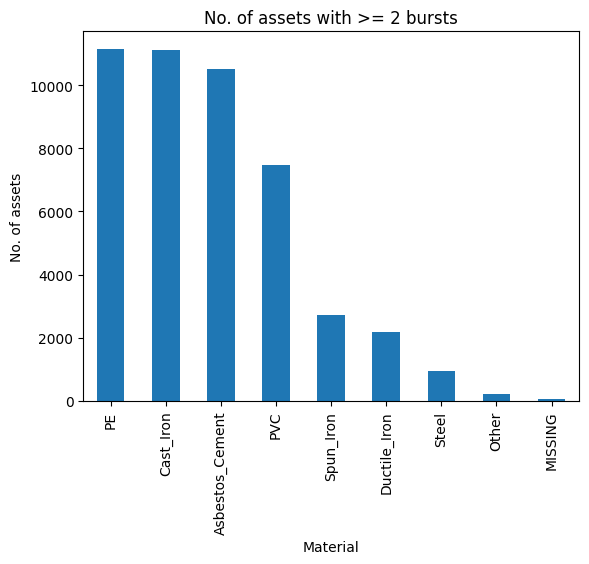

In [ ]:
assets_bursts_soil_frequent["Material"].value_counts().plot(kind = "bar",
                                                                                                       ylabel = "No. of assets",
                                                                                                       title = "No. of assets with >= 2 bursts")

In [ ]:
# identify the latest two bursts for each asset

index = assets_bursts_soil_frequent.groupby("Asset.ID")["Raised.Date"].nlargest(2).reset_index(level = 0, drop = True).index

In [ ]:
# subset data to contain only latest two bursts

assets_bursts_soil_frequent_2 = assets_bursts_soil_frequent.loc[index]

In [ ]:
# sort using Asset ID and Date

assets_bursts_soil_frequent_2 = assets_bursts_soil_frequent_2.sort_values(by = ["Asset.ID", "Raised.Date"])


In [ ]:
# introduce a pivot column

burst = ["First", "Second"] * 10764

assets_bursts_soil_frequent_2["Burst"] = burst

In [ ]:
# pivot date column

frequent_bursts_2_tidy = assets_bursts_soil_frequent_2.pivot(values = "Raised.Date", columns = "Burst", index = "Asset.ID").reset_index()


In [ ]:
# merge pivoted column with the original assets and soil data

attributes = pd.merge(frequent_bursts_2_tidy, assets_cleaned, how = "inner", on = "Asset.ID")

attributes = pd.merge(attributes, soil, on = "Asset.ID", how = "inner")


In [ ]:
# calculate and add time-to-break attribute

time_to_break = attributes["Second"] - attributes["First"]

attributes["Time-to-break"] = time_to_break

In [ ]:
# save attributes

attributes.to_csv("/content/drive/MyDrive/MSc project/attributes.csv", encoding ='latin1', index=False)